In [2]:
from pathlib import Path
import pandas as pd

In [3]:
DATA_PATH = (
    Path("..")
    / "data"
    / "processed"
    / "daphnet_integrated.parquet"
)

print("Dataset found:", DATA_PATH.exists())

Dataset found: True


In [4]:
df = pd.read_parquet(DATA_PATH)

print("Dataset loaded successfully.")
print("Rows:", len(df))

Dataset loaded successfully.
Rows: 1917887


In [5]:
preprocessed_df = df.drop(columns="source_file").copy()

print("Rows before preprocessing:", len(preprocessed_df))

Rows before preprocessing: 1917887


In [6]:
preprocessed_df = preprocessed_df[
    preprocessed_df["annotation"].isin([1, 2])
].copy()

print("Rows after removing outside-experiment samples:", len(preprocessed_df))

Rows after removing outside-experiment samples: 1140835


In [7]:
preprocessed_df["fog"] = preprocessed_df["annotation"].map({
    1: 0,
    2: 1
})

In [8]:
print("No FoG samples:", (preprocessed_df["fog"] == 0).sum())
print("FoG samples:", (preprocessed_df["fog"] == 1).sum())

No FoG samples: 1030050
FoG samples: 110785


In [9]:
preprocessed_df = preprocessed_df.sort_values(
    by=["participant_id", "recording_id", "time_ms"]
).reset_index(drop=True)

In [10]:
print(
    "Total missing values:",
    preprocessed_df.isna().sum().sum()
)

Total missing values: 0


Confirming TimeStamp Ordering

In [11]:
time_order_check = (
    preprocessed_df
    .groupby(["participant_id", "recording_id"])["time_ms"]
    .agg(lambda values: values.is_monotonic_increasing)
)

time_order_check

participant_id  recording_id
S01             R01             True
                R02             True
S02             R01             True
                R02             True
S03             R01             True
                R02             True
                R03             True
S04             R01             True
S05             R01             True
                R02             True
S06             R01             True
                R02             True
S07             R01             True
                R02             True
S08             R01             True
S09             R01             True
S10             R01             True
Name: time_ms, dtype: bool

In [12]:
print("Final rows:", len(preprocessed_df))
print("Final columns:", len(preprocessed_df.columns))
print(preprocessed_df.head())

Final rows: 1140835
Final columns: 14
   time_ms  ankle_forward_mg  ankle_vertical_mg  ankle_lateral_mg  \
0   750000               -30                990               326   
1   750015               -30               1000               356   
2   750031               -20                990               336   
3   750046               -20               1000               316   
4   750062                 0                990               316   

   thigh_forward_mg  thigh_vertical_mg  thigh_lateral_mg  trunk_forward_mg  \
0               -45                972               181               -38   
1               -18                981               212               -48   
2                18                981               222               -38   
3                36                990               222               -19   
4                36                990               212               -29   

   trunk_vertical_mg  trunk_lateral_mg  annotation participant_id  \
0        

# 2 Second Contigouous Window

window_size = 128
step_size = 128

In [13]:
window_size = 128
step_size = 128

In [14]:
window_records = []

In [15]:
for (participant_id, recording_id), recording in preprocessed_df.groupby(
    ["participant_id", "recording_id"]
):
    
    recording = recording.sort_values("time_ms").reset_index(drop=True)

    window_number = 0

    for start in range(
        0,
        len(recording) - window_size + 1,
        step_size
    ):
        
        window = recording.iloc[start:start + window_size]

        window_label = int(window["fog"].mean() >= 0.5)

        window_records.append({
            "participant_id": participant_id,
            "recording_id": recording_id,
            "window_number": window_number,
            "start_time_ms": window["time_ms"].iloc[0],
            "end_time_ms": window["time_ms"].iloc[-1],
            "fog": window_label,
            "number_of_samples": len(window)
        })

        window_number += 1

In [16]:
window_df = pd.DataFrame(window_records)

print("Number of windows:", len(window_df))
window_df.head()

Number of windows: 8912


,participant_id,recording_id,window_number,start_time_ms,end_time_ms,fog,number_of_samples
0,S01,R01,0,750000,751984,0,128
1,S01,R01,1,752000,753984,0,128
2,S01,R01,2,754000,755984,0,128
3,S01,R01,3,756000,757984,0,128
4,S01,R01,4,758000,759984,0,128


In [17]:
window_df["number_of_samples"].value_counts()

number_of_samples
128    8912
Name: count, dtype: int64

In [18]:
print("No FoG windows:", (window_df["fog"] == 0).sum())
print("FoG windows:", (window_df["fog"] == 1).sum())

No FoG windows: 8056
FoG windows: 856


In [19]:
first_window = window_df.iloc[0]

print("Window start time:", first_window["start_time_ms"])
print("Window end time:", first_window["end_time_ms"])
print("Window label:", first_window["fog"])
print("Number of readings:", first_window["number_of_samples"])

Window start time: 750000
Window end time: 751984
Window label: 0
Number of readings: 128


In [20]:
window_df[
    ["participant_id", "recording_id", "window_number", "fog"]
].head(10)

,participant_id,recording_id,window_number,fog
0,S01,R01,0,0
1,S01,R01,1,0
2,S01,R01,2,0
3,S01,R01,3,0
4,S01,R01,4,0
5,S01,R01,5,0
6,S01,R01,6,0
7,S01,R01,7,0
8,S01,R01,8,0
9,S01,R01,9,0


In [21]:
import matplotlib.pyplot as plt

In [22]:
selected_window = window_df.iloc[0]

selected_participant = selected_window["participant_id"]
selected_recording = selected_window["recording_id"]
selected_window_number = selected_window["window_number"]

print("Participant:", selected_participant)
print("Recording:", selected_recording)
print("Window number:", selected_window_number)
print("FoG label:", selected_window["fog"])

Participant: S01
Recording: R01
Window number: 0
FoG label: 0


In [23]:
recording_data = preprocessed_df[
    (preprocessed_df["participant_id"] == selected_participant)
    & (preprocessed_df["recording_id"] == selected_recording)
].sort_values("time_ms").reset_index(drop=True)

In [24]:
start_row = int(selected_window_number * window_size)

one_window = recording_data.iloc[
    start_row:start_row + window_size
].copy()

In [25]:
one_window["time_seconds"] = (
    one_window["time_ms"] - one_window["time_ms"].iloc[0]
) / 1000

In [27]:
print(preprocessed_df.columns.tolist())

['time_ms', 'ankle_forward_mg', 'ankle_vertical_mg', 'ankle_lateral_mg', 'thigh_forward_mg', 'thigh_vertical_mg', 'thigh_lateral_mg', 'trunk_forward_mg', 'trunk_vertical_mg', 'trunk_lateral_mg', 'annotation', 'participant_id', 'recording_id', 'fog']


In [28]:
sensor_columns = [
    column
    for column in preprocessed_df.columns
    if column.endswith("_mg")
]

print(sensor_columns)

['ankle_forward_mg', 'ankle_vertical_mg', 'ankle_lateral_mg', 'thigh_forward_mg', 'thigh_vertical_mg', 'thigh_lateral_mg', 'trunk_forward_mg', 'trunk_vertical_mg', 'trunk_lateral_mg']


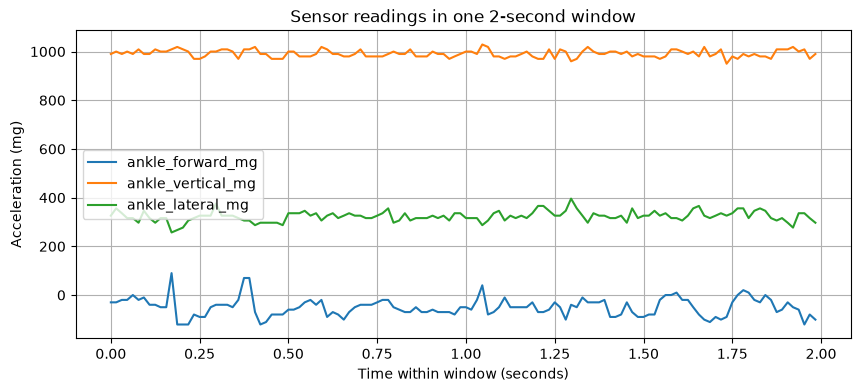

In [29]:
plt.figure(figsize=(10, 4))

for column in sensor_columns[:3]:
    plt.plot(
        one_window["time_seconds"],
        one_window[column],
        label=column
    )

plt.xlabel("Time within window (seconds)")
plt.ylabel("Acceleration (mg)")
plt.title("Sensor readings in one 2-second window")
plt.legend()
plt.grid(True)
plt.show()

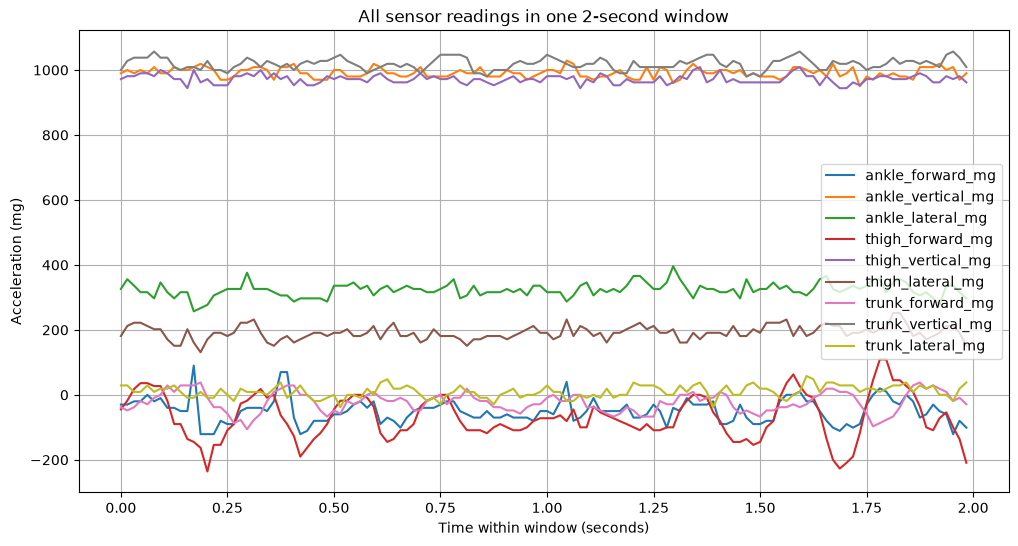

In [30]:
plt.figure(figsize=(12, 6))

for column in sensor_columns:
    plt.plot(
        one_window["time_seconds"],
        one_window[column],
        label=column
    )

plt.xlabel("Time within window (seconds)")
plt.ylabel("Acceleration (mg)")
plt.title("All sensor readings in one 2-second window")
plt.legend()
plt.grid(True)
plt.show()